In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV file
df = pd.read_csv('/content/salaries.csv')

# 2. Clean the data
# Trim whitespace from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows.")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0])

# Drop rows with missing values (or handle them accordingly)
df.dropna(inplace=True)
print(f"\nData shape after dropping missing values: {df.shape}")

# Optional: convert column names to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 3. Process the data
# (Add any transformations or feature engineering here)

# 4. Analyze the data

# Summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Value counts for categorical variables
for col in df.select_dtypes(include='object').columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())





Removed 44340 duplicate rows.

Missing values per column:
Series([], dtype: int64)

Data shape after dropping missing values: (44244, 11)

Summary Statistics:
           work_year experience_level employment_type       job_title  \
count   44244.000000            44244           44244           44244   
unique           NaN                4               4             312   
top              NaN               SE              FT  Data Scientist   
freq             NaN            23474           43821            5207   
mean     2024.065952              NaN             NaN             NaN   
std         0.713820              NaN             NaN             NaN   
min      2020.000000              NaN             NaN             NaN   
25%      2024.000000              NaN             NaN             NaN   
50%      2024.000000              NaN             NaN             NaN   
75%      2024.000000              NaN             NaN             NaN   
max      2025.000000              NaN 

<ipython-input-2-724ab3f94fa5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='job_title', y='salary', estimator='mean', palette='viridis')


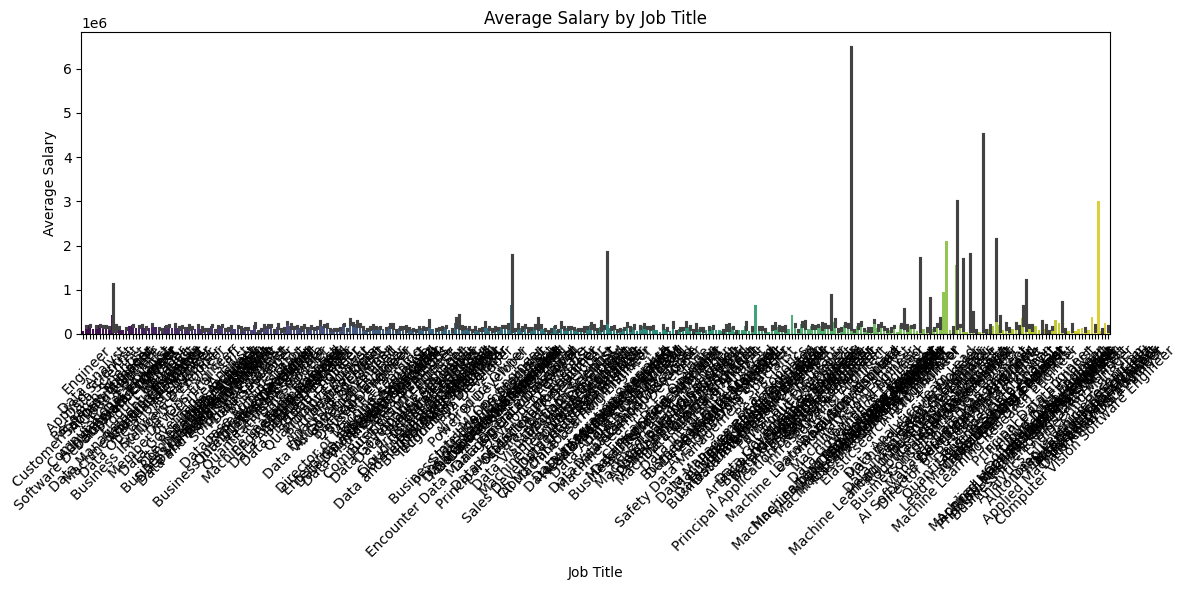

In [2]:
#Bar Plot – Average Salary by Job Title

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='job_title', y='salary', estimator='mean', palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Salary by Job Title')
plt.ylabel('Average Salary')
plt.xlabel('Job Title')S
plt.tight_layout()
plt.show()


<ipython-input-3-fb25c2781b24>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary', palette='pastel')


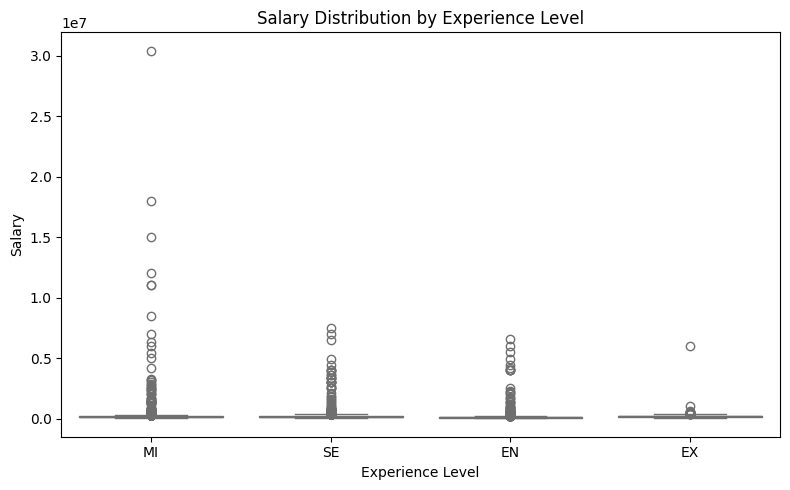

In [3]:
#Box Plot – Salary by Experience Level

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='experience_level', y='salary', palette='pastel')
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()


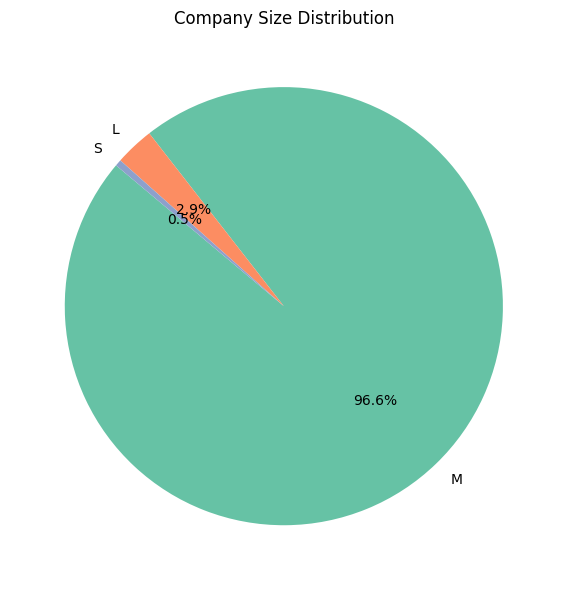

In [4]:
#Pie Chart – Distribution of Company Sizes

company_size_counts = df['company_size'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(company_size_counts, labels=company_size_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Company Size Distribution')
plt.tight_layout()
plt.show()


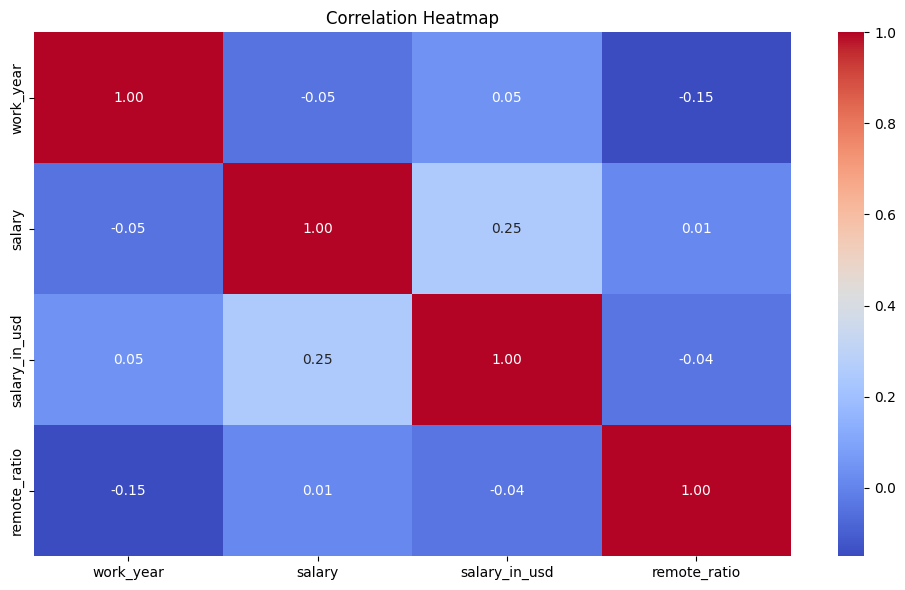

In [5]:
#Heatmap – Correlation Between Numeric Columns

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


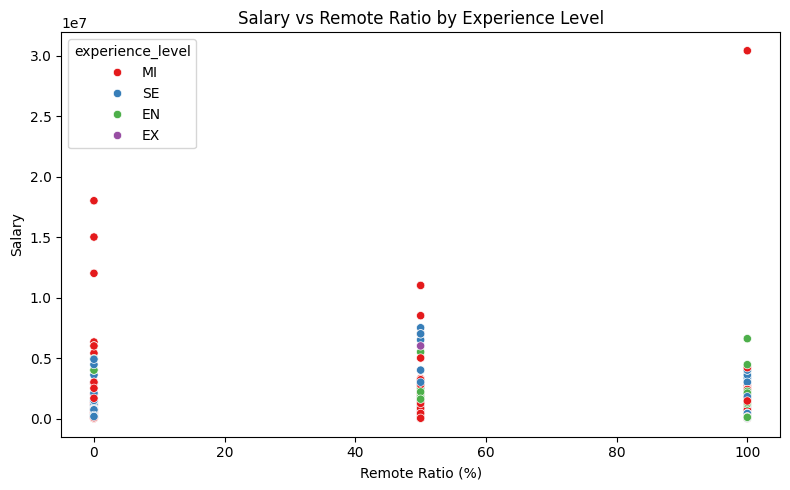

In [7]:
# Scatter Plot – Salary vs Remote Ratio

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='remote_ratio', y='salary', hue='experience_level', palette='Set1')
plt.title('Salary vs Remote Ratio by Experience Level')
plt.xlabel('Remote Ratio (%)')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()
